<a href="https://colab.research.google.com/github/Tenka04/Machine-Vision-Lab/blob/main/MV_Prac1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving 4K-IP-camera-infrared-scaled.jpg to 4K-IP-camera-infrared-scaled (1).jpg


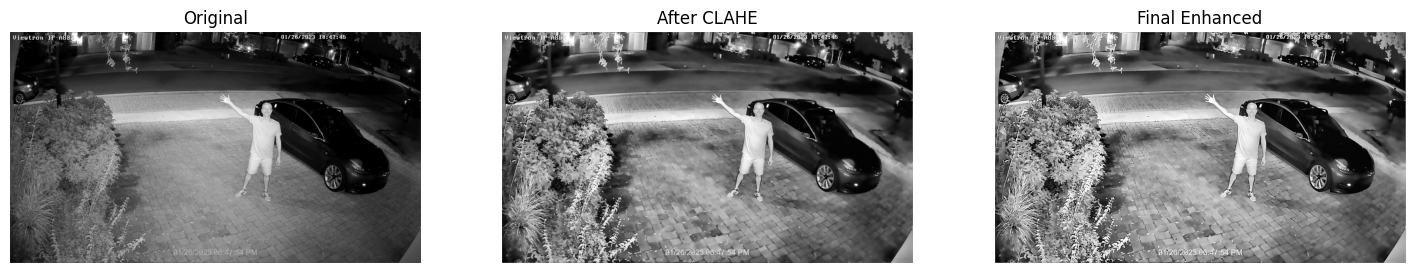

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================
# Night CCTV Image Enhancement (Google Colab)
# ============================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# --------------------------------------------
# Upload Image
# --------------------------------------------
uploaded = files.upload()

filename = list(uploaded.keys())[0]

# Read image
img = cv2.imread(filename)

# Convert BGR → RGB
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Noise Removal
denoise = cv2.fastNlMeansDenoising(gray, None, 10, 7, 21)

# CLAHE
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
clahe = clahe.apply(denoise)

# Gamma Correction
gamma = 1.2
lookUpTable = np.empty((1,256), np.uint8)

for i in range(256):
    lookUpTable[0,i] = np.clip(pow(i/255.0, 1.0/gamma)*255.0,0,255)

gamma_img = cv2.LUT(clahe, lookUpTable)

# Unsharp Mask
gaussian = cv2.GaussianBlur(gamma_img,(0,0),3)
final = cv2.addWeighted(gamma_img,1.8,gaussian,-0.8,0)

# --------------------------------------------
# Save Output
# --------------------------------------------
cv2.imwrite("enhanced_cctv.jpg", final)

# --------------------------------------------
# Display Images
# --------------------------------------------
plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(clahe, cmap="gray")
plt.title("After CLAHE")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(final, cmap="gray")
plt.title("Final Enhanced")
plt.axis("off")

plt.show()

# --------------------------------------------
# Download Result
# --------------------------------------------
files.download("enhanced_cctv.jpg")